# Final image dataset merge

Purpose: merge MIDV, FantasyID, and FMIDV into one final image metadata table,
standardize binary labels, define `group_key`, and save `image_dataset_final.csv`.


## 1. Setup and file paths
This section defines the input metadata files and the output path for the final merged image dataset.

In [2]:
from pathlib import Path
import sys
import pandas as pd

project_root = Path.cwd().parent
processed_dir = project_root / "data" / "processed"
sys.path.append(str(project_root / "src"))

from image_dataset_merge_final import merge_image_metadata, save_metadata, print_summary

In [3]:
midv_csv = processed_dir / "midv_image_manifest.csv"
fantasyid_csv = processed_dir / "fantasyid_image_manifest.csv"
fmidv_csv = processed_dir / "fmidv_image_manifest.csv"
output_csv = processed_dir / "image_dataset_final.csv"

print("MIDV:", midv_csv)
print("FantasyID:", fantasyid_csv)
print("FMIDV:", fmidv_csv)
print("Output:", output_csv)

MIDV: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed\midv_image_manifest.csv
FantasyID: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed\fantasyid_image_manifest.csv
FMIDV: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed\fmidv_image_manifest.csv
Output: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed\image_dataset_final.csv


In [4]:
df_midv = pd.read_csv(midv_csv)
df_fantasy = pd.read_csv(fantasyid_csv)
df_fmidv = pd.read_csv(fmidv_csv)

print("MIDV shape:", df_midv.shape)
print("FantasyID shape:", df_fantasy.shape)
print("FMIDV shape:", df_fmidv.shape)

MIDV shape: (4000, 12)
FantasyID shape: (3284, 18)
FMIDV shape: (2880, 17)


## Merge cleaned manifests

The manifests are already standardized and contain the final binary label and `group_key`. The merge step concatenates them into one final image dataset.

In [5]:
df_merged = merge_image_metadata(
    midv_csv=midv_csv,
    fantasyid_csv=fantasyid_csv,
    fmidv_csv=fmidv_csv,
)

print_summary(df_merged)
save_metadata(df_merged, output_csv)

Final shape: (10164, 9)

Class counts:
image_class
forged       5231
bona_fide    4933
Name: count, dtype: int64

Source x class:
image_class     bona_fide  forged
source_dataset                   
fantasyid             933    2351
fmidv                   0    2880
midv                 4000       0

Unique groups by source:
source_dataset
fantasyid     362
fmidv         720
midv         1000
Name: group_key, dtype: int64

Duplicate image paths:
0
Saved merged metadata to: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\data\processed\image_dataset_final.csv


In [6]:
df_merged = merge_image_metadata(
    midv_csv=midv_csv,
    fantasyid_csv=fantasyid_csv,
    fmidv_csv=fmidv_csv,
)

In [9]:
print(df_merged.columns)

Index(['image_path', 'source_dataset', 'image_class', 'group_key', 'doc_type',
       'source_type', 'file_name', 'split_source', 'original_label'],
      dtype='object')


image_class     bona_fide  forged
source_dataset                   
fantasyid             933    2351
fmidv                   0    2880
midv                 4000       0


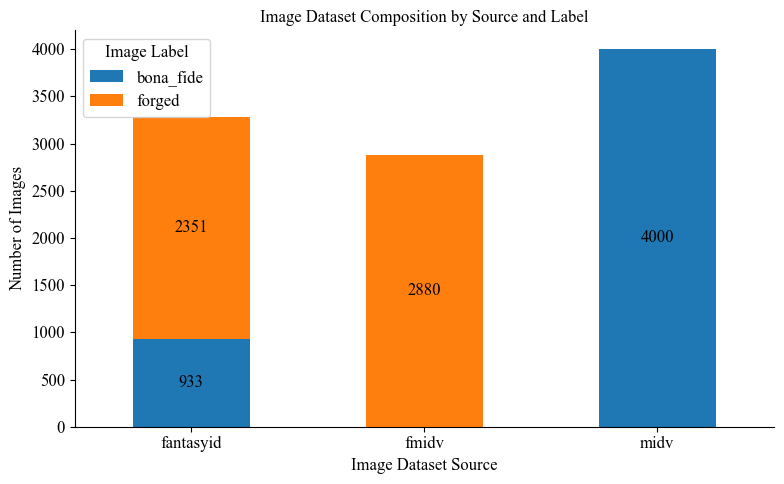

In [16]:
import matplotlib.pyplot as plt

# Use your actual column names
source_col = "source_dataset"
label_col = "image_class"

# Set font
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 12

# Count images by source and label
source_label_counts = (
    df_merged
    .groupby([source_col, label_col])
    .size()
    .unstack(fill_value=0)
)

print(source_label_counts)

# Plot stacked bar chart
ax = source_label_counts.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

ax.set_title("Image Dataset Composition by Source and Label", fontsize=12)
ax.set_xlabel("Image Dataset Source", fontsize=12)
ax.set_ylabel("Number of Images", fontsize=12)
ax.legend(title="Image Label", fontsize=12, title_fontsize=12)

# Add numbers to each part of the stacked bars
for container in ax.containers:
    labels = [int(v.get_height()) if v.get_height() > 0 else "" for v in container]
    ax.bar_label(container, labels=labels, label_type="center", fontsize=12)

# Clean style
ax.spines[["top", "right"]].set_visible(False)
plt.xticks(rotation=0, fontsize=12)
plt.yticks(fontsize=12)

plt.tight_layout()

plt.show()

## Conclusion

The final merged image dataset was created successfully and saved as `image_dataset_final.csv`. This file is used as the input for the later group-based split construction.